In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_circles

# 2 variables (x1, x2) and 2 classes (target: 0/1) with circular structure
X, y = make_circles(n_samples=5000, factor=0.45, noise=0.15, random_state=42)

dataset = pd.DataFrame(X, columns=["x1", "x2"])
dataset["target"] = y

dataset.head()

,x1,x2,target
0,-0.520676,-0.460194,0
1,0.481322,-0.117592,1
2,0.447442,0.201047,1
3,-0.912087,0.565649,0
4,-0.031424,0.857094,0


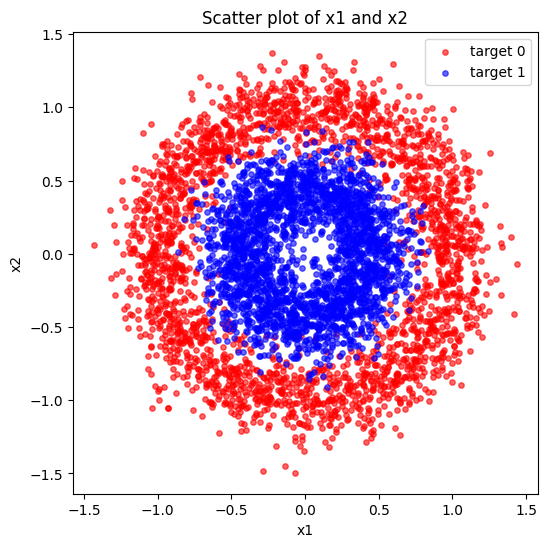

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(dataset.loc[dataset["target"] == 0, "x1"],
			dataset.loc[dataset["target"] == 0, "x2"],
			c="red", alpha=0.6, s=15, label="target 0")
plt.scatter(dataset.loc[dataset["target"] == 1, "x1"],
			dataset.loc[dataset["target"] == 1, "x2"],
			c="blue", alpha=0.6, s=15, label="target 1")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Scatter plot of x1 and x2")
plt.legend()
plt.show()

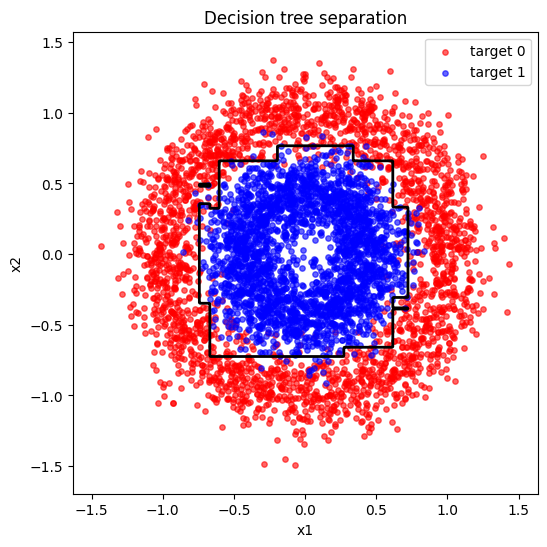

Training accuracy: 0.965
Tree depth: 6
Number of leaves: 41


In [18]:
from sklearn.tree import DecisionTreeClassifier

#use a fixed depth of 5 to prevent overfitting on this dataset
tree_model = DecisionTreeClassifier(max_depth=6, random_state=42)
tree_model.fit(X, y)

x1_min, x1_max = dataset["x1"].min() - 0.2, dataset["x1"].max() + 0.2
x2_min, x2_max = dataset["x2"].min() - 0.2, dataset["x2"].max() + 0.2

xx1, xx2 = np.meshgrid(
	np.linspace(x1_min, x1_max, 400),
	np.linspace(x2_min, x2_max, 400)
)

grid = np.c_[xx1.ravel(), xx2.ravel()]
pred_grid = tree_model.predict(grid).reshape(xx1.shape)

plt.figure(figsize=(6, 6))
plt.contour(xx1, xx2, pred_grid, levels=[0.5], colors="black", linewidths=2)
plt.scatter(
	dataset.loc[dataset["target"] == 0, "x1"],
	dataset.loc[dataset["target"] == 0, "x2"],
	c="red", alpha=0.6, s=15, label="target 0"
)
plt.scatter(
	dataset.loc[dataset["target"] == 1, "x1"],
	dataset.loc[dataset["target"] == 1, "x2"],
	c="blue", alpha=0.6, s=15, label="target 1"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision tree separation")
plt.legend()
plt.show()

print("Training accuracy:", tree_model.score(X, y))
print("Tree depth:", tree_model.get_depth())
print("Number of leaves:", tree_model.get_n_leaves())

Selected ccp_alpha (CV): 0.000615


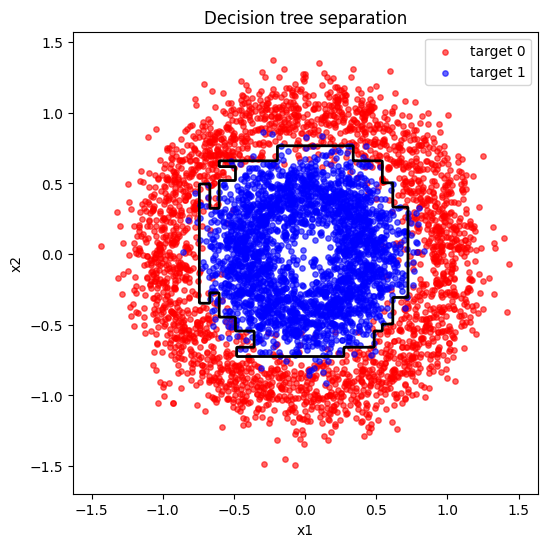

Training accuracy: 0.9716
Tree depth: 11
Number of leaves: 33


In [5]:
from sklearn.tree import DecisionTreeClassifier

# Cost-complexity pruning: choose stopping condition (ccp_alpha) with 5-fold CV
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X, y)
ccp_alphas = np.unique(path.ccp_alphas)

# Drop the largest alpha (usually collapses to a trivial tree)
if ccp_alphas.size > 1:
	ccp_alphas = ccp_alphas[:-1]

#perform 5-fold CV for each candidate alpha
rng = np.random.RandomState(42)
indices = rng.permutation(len(y))
folds = np.array_split(indices, 5)

alpha_scores = []
for alpha in ccp_alphas:
	fold_scores = []
	for i in range(5):
		val_idx = folds[i]
		train_idx = np.concatenate([folds[j] for j in range(5) if j != i])

		model = DecisionTreeClassifier(random_state=42, ccp_alpha=float(alpha))
		model.fit(X[train_idx], y[train_idx])
		fold_scores.append(model.score(X[val_idx], y[val_idx]))

	alpha_scores.append(np.mean(fold_scores))

best_alpha = float(ccp_alphas[int(np.argmax(alpha_scores))]) if len(ccp_alphas) else 0.0
tree_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)

print(f"Selected ccp_alpha (CV): {best_alpha:.6f}")
tree_model.fit(X, y)

x1_min, x1_max = dataset["x1"].min() - 0.2, dataset["x1"].max() + 0.2
x2_min, x2_max = dataset["x2"].min() - 0.2, dataset["x2"].max() + 0.2

xx1, xx2 = np.meshgrid(
	np.linspace(x1_min, x1_max, 400),
	np.linspace(x2_min, x2_max, 400)
)

grid = np.c_[xx1.ravel(), xx2.ravel()]
pred_grid = tree_model.predict(grid).reshape(xx1.shape)

plt.figure(figsize=(6, 6))
plt.contour(xx1, xx2, pred_grid, levels=[0.5], colors="black", linewidths=2)
plt.scatter(
	dataset.loc[dataset["target"] == 0, "x1"],
	dataset.loc[dataset["target"] == 0, "x2"],
	c="red", alpha=0.6, s=15, label="target 0"
)
plt.scatter(
	dataset.loc[dataset["target"] == 1, "x1"],
	dataset.loc[dataset["target"] == 1, "x2"],
	c="blue", alpha=0.6, s=15, label="target 1"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision tree separation")
plt.legend()
plt.show()

print("Training accuracy:", tree_model.score(X, y))
print("Tree depth:", tree_model.get_depth())
print("Number of leaves:", tree_model.get_n_leaves())

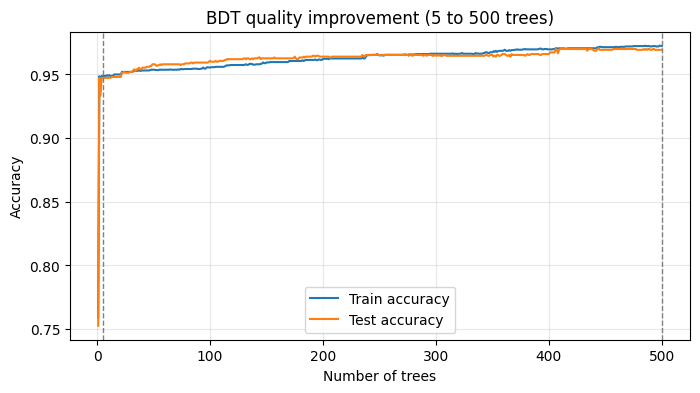

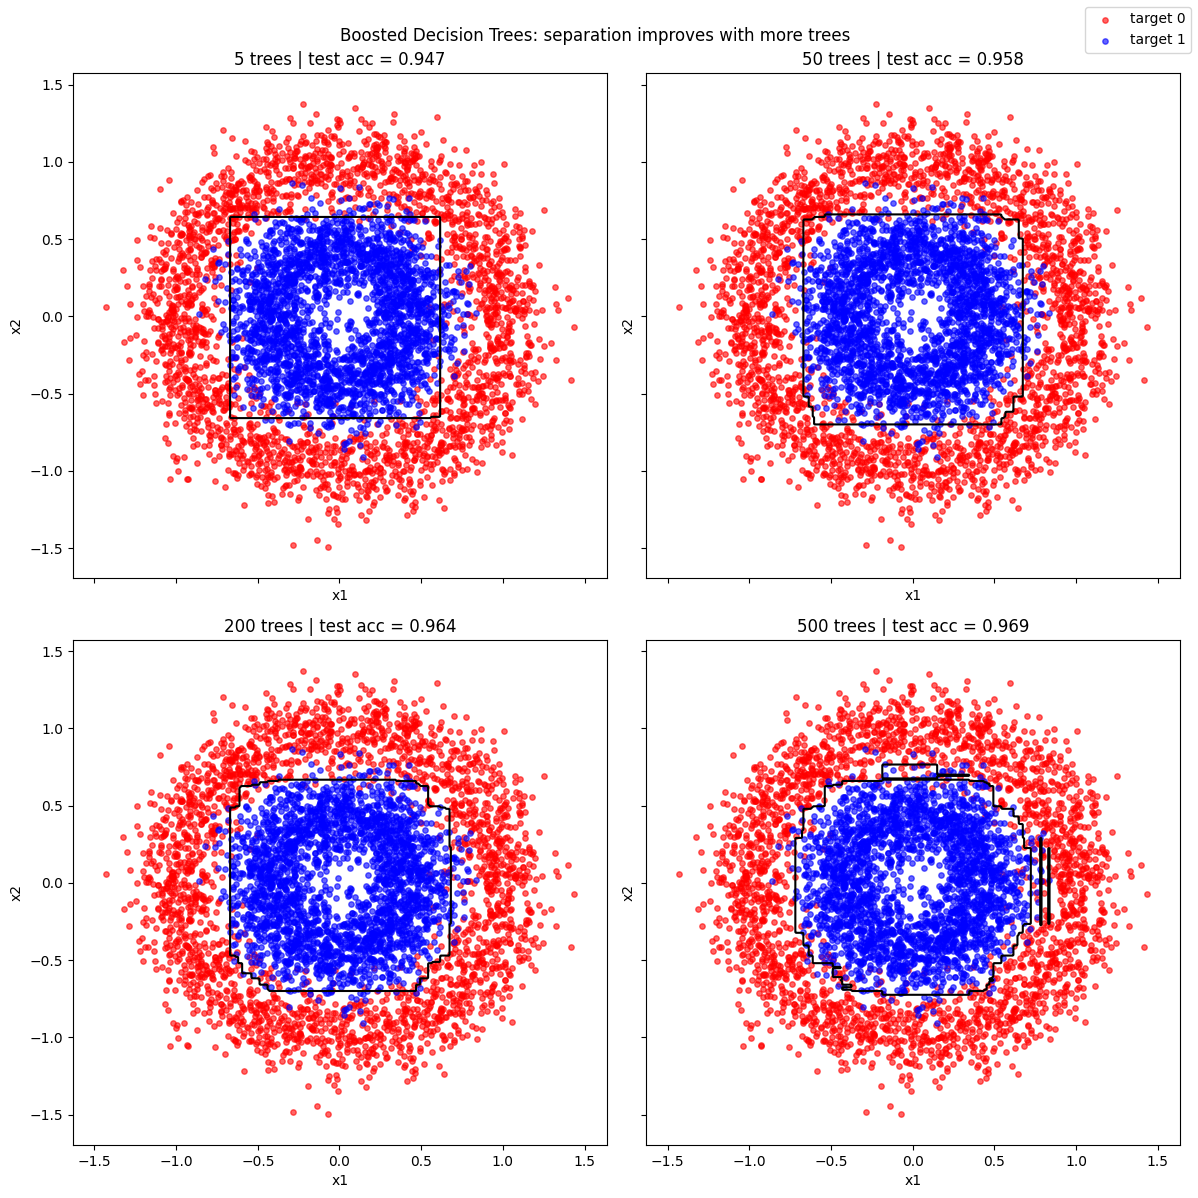

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Train/test split to measure generalization quality
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.3, random_state=42, stratify=y
)

# 1) Quality improvement from 5 to 500 trees
# limit the depth to 2 to prevent overfitting and show the improvement from more trees
gbdt_500 = GradientBoostingClassifier(
	n_estimators=500, learning_rate=0.05, max_depth=2, random_state=42
)
gbdt_500.fit(X_train, y_train)

train_acc = []
test_acc = []
for y_pred_tr, y_pred_te in zip(gbdt_500.staged_predict(X_train), gbdt_500.staged_predict(X_test)):
	train_acc.append(accuracy_score(y_train, y_pred_tr))
	test_acc.append(accuracy_score(y_test, y_pred_te))

plt.figure(figsize=(8, 4))
plt.plot(range(1, 501), train_acc, label="Train accuracy")
plt.plot(range(1, 501), test_acc, label="Test accuracy")
plt.axvline(5, color="gray", linestyle="--", linewidth=1)
plt.axvline(500, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Number of trees")
plt.ylabel("Accuracy")
plt.title("BDT quality improvement (5 to 500 trees)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 2) Decision boundaries at selected numbers of trees
selected_trees = [5, 50, 200, 500]
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True)

for ax, n_trees in zip(axes.ravel(), selected_trees):
	model = GradientBoostingClassifier(
		n_estimators=n_trees, learning_rate=0.05, max_depth=2, random_state=42
	)
	model.fit(X_train, y_train)

	pred_grid_n = model.predict(grid).reshape(xx1.shape)
	test_score = model.score(X_test, y_test)

	#ax.contourf(xx1, xx2, pred_grid_n, levels=[-0.5, 0.5, 1.5], alpha=0.25, cmap="bwr")
	ax.contour(xx1, xx2, pred_grid_n, levels=[0.5], colors="black", linewidths=1.5)

	ax.scatter(
		dataset.loc[dataset["target"] == 0, "x1"],
		dataset.loc[dataset["target"] == 0, "x2"],
		c="red", s=15, alpha=0.6, label="target 0"
	)
	ax.scatter(
		dataset.loc[dataset["target"] == 1, "x1"],
		dataset.loc[dataset["target"] == 1, "x2"],
		c="blue", s=15, alpha=0.6, label="target 1"
	)
	ax.set_title(f"{n_trees} trees | test acc = {test_score:.3f}")
	ax.set_xlabel("x1")
	ax.set_ylabel("x2")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Boosted Decision Trees: separation improves with more trees", y=0.98)
plt.tight_layout()
plt.show()

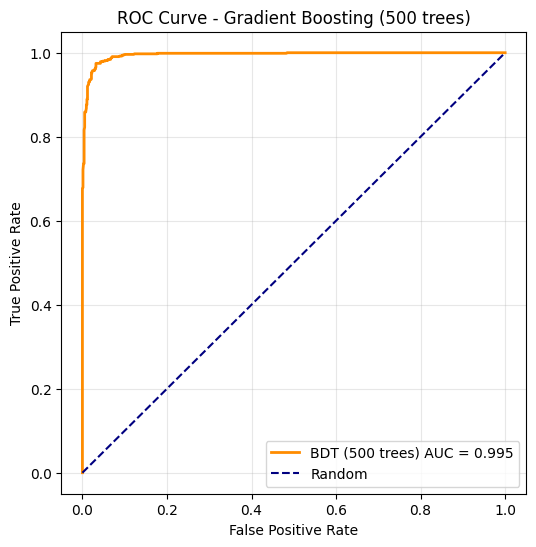

In [7]:
from sklearn.metrics import roc_curve, auc

# ROC on test set for the 500-tree boosted model
y_score = gbdt_500.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"BDT (500 trees) AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting (500 trees)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

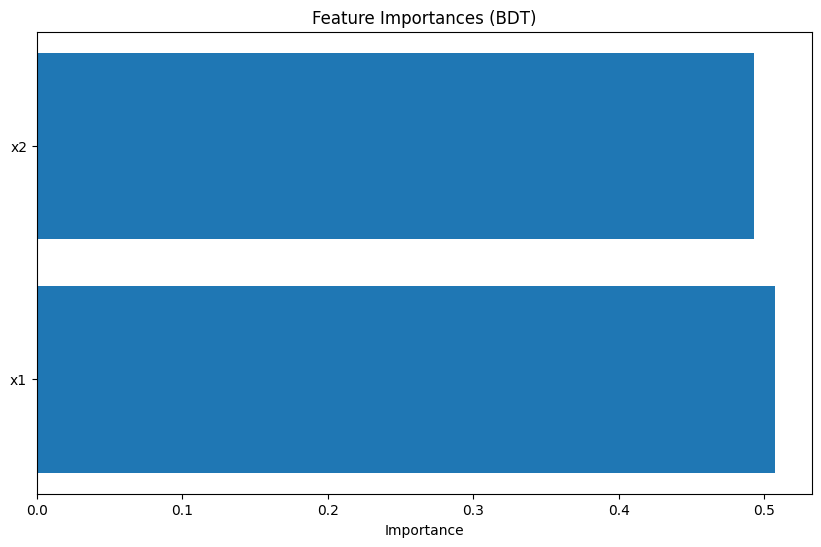

In [8]:
# Feature importance for BDT
bdt_importances = gbdt_500.feature_importances_
plt.figure(figsize=(10, 6))
feature_names = ['x1','x2']  # All columns except the last one are features
plt.barh(feature_names, bdt_importances)
plt.xlabel('Importance')
plt.title('Feature Importances (BDT)')
plt.show()